# z621 - Clustering bruto por tonelaje MENSUAL de cliente

## Que hace este notebook
Es una segunda version del clustering bruto de `z619`, con una correccion sobre como se rankea a los clientes.

- **`z619` (version original, NO se borra, queda como parte del historial del experimento):** sumaba el tonelaje de CADA cliente a lo largo de TODO el historial (todos los meses juntos) para ordenarlo en el long tail. Ese cluster era fijo para siempre -- un cliente grande quedaba en el mismo cluster en enero y en diciembre, sin importar como haya vendido cada mes puntual.
- **`z621` (esta version, corregida):** en cambio, calcula el tonelaje de cada cliente MES A MES, y arma el long tail y el particionado en K clusters DE NUEVO, para cada periodo por separado. Un mismo cliente puede terminar en distinto cluster segun el mes, dependiendo de cuanto vendio ESE mes.

Este cambio se hizo porque el resultado final entrenado sobre `z619` dio un Total Error Rate muy malo (9.557) en Kaggle -- el clustering fijo por ano fue una de las hipotesis de correccion, junto con el ajuste de tweedie ya aplicado en `z620`.

Fuente: `tb_FE_CP.parquet` (salida de `z618`, features escaladas). Salida: carpeta y archivo NUEVOS (`CP_CLUSTER_BRUTO_MENSUAL/tb_FE_CP_con_cluster_mensual.parquet`), sin pisar la salida de `z619`.

In [1]:
!pip install -q polars pyarrow matplotlib

In [2]:
import os
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [3]:
PARAM = {
    'experimento': 'CP_CLUSTER_BRUTO_MENSUAL',
    'features_path': '/home/ds/exp/CP_FE01/tb_FE_CP.parquet',
    'k_clusters': 10   # ajustar segun el tamano resultante de cada cluster (ver diagnostico abajo)
}

ruta = os.path.join('/home/ds/exp', PARAM['experimento'])
os.makedirs(ruta, exist_ok=True)
print(ruta)

/home/ds/exp/CP_CLUSTER_BRUTO_MENSUAL


## 1. Tonelaje por cliente, MES A MES (no acumulado del ano)

In [4]:
df = pl.read_parquet(PARAM['features_path'])

tn_por_cliente_mes = df.group_by(["customer_id", "periodo"]).agg(
    pl.col("tn0").sum().alias("tn_mes_cliente")
)
print(tn_por_cliente_mes.shape)
tn_por_cliente_mes.head(10)

(18992, 3)


customer_id,periodo,tn_mes_cliente
i64,i64,f64
10074,201907,200.12581
10262,201807,9.50331
10263,201701,0.91075
10293,201908,0.46202
10343,201710,2.6663
10345,201911,23.09345
10372,201701,8.08985
10373,201912,3.63859
10405,201712,2.77661


## 2. Grafico long tail (ejemplo: periodo 201912)
El orden de los clientes cambia mes a mes -- este grafico es solo una foto representativa de un mes puntual, no el criterio de particion en si.

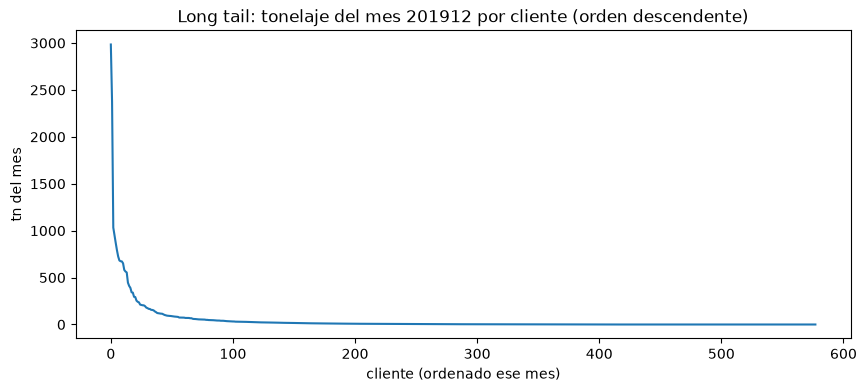

In [5]:
ejemplo = tn_por_cliente_mes.filter(pl.col("periodo") == 201912).sort("tn_mes_cliente", descending=True)
valores = ejemplo["tn_mes_cliente"].to_numpy()

plt.figure(figsize=(10, 4))
plt.plot(valores)
plt.title("Long tail: tonelaje del mes 201912 por cliente (orden descendente)")
plt.xlabel("cliente (ordenado ese mes)")
plt.ylabel("tn del mes")
plt.savefig(os.path.join(ruta, "long_tail_201912.png"))
plt.show()

## 3. Particion en K clusters, RECALCULADA para cada periodo
Para cada mes: ordeno los clientes por su venta de ESE mes (mayor a menor primero, despues el resto) y los parto en K grupos consecutivos. El `cluster_id` de un cliente puede ser distinto en enero que en diciembre.

In [6]:
K = PARAM['k_clusters']

tn_por_cliente_mes = tn_por_cliente_mes.sort(["periodo", "tn_mes_cliente"], descending=[False, True])
tn_por_cliente_mes = tn_por_cliente_mes.with_columns(
    (pl.col("customer_id").cum_count().over("periodo") - 1).alias("orden")
)
tn_por_cliente_mes = tn_por_cliente_mes.with_columns(
    pl.col("customer_id").count().over("periodo").alias("n_clientes_mes")
)
tn_por_cliente_mes = tn_por_cliente_mes.with_columns(
    (pl.col("orden") * K // pl.col("n_clientes_mes")).alias("cluster_id")
)

tb_clusters = tn_por_cliente_mes.select(["customer_id", "periodo", "cluster_id"])
print(tb_clusters.group_by(["periodo", "cluster_id"]).len().sort(["periodo", "cluster_id"]).head(20))

shape: (20, 3)
┌─────────┬────────────┬─────┐
│ periodo ┆ cluster_id ┆ len │
│ ---     ┆ ---        ┆ --- │
│ i64     ┆ u32        ┆ u32 │
╞═════════╪════════════╪═════╡
│ null    ┆ 0          ┆ 1   │
│ 201701  ┆ 0          ┆ 43  │
│ 201701  ┆ 1          ┆ 43  │
│ 201701  ┆ 2          ┆ 42  │
│ 201701  ┆ 3          ┆ 43  │
│ …       ┆ …          ┆ …   │
│ 201702  ┆ 4          ┆ 47  │
│ 201702  ┆ 5          ┆ 47  │
│ 201702  ┆ 6          ┆ 48  │
│ 201702  ┆ 7          ┆ 47  │
│ 201702  ┆ 8          ┆ 47  │
└─────────┴────────────┴─────┘


## 4. Unir al dataset
Join por `(customer_id, periodo)` -- a diferencia de `z619` que unia solo por `customer_id`, aca el cluster depende tambien del mes.

In [7]:
df = df.join(tb_clusters, on=["customer_id", "periodo"], how="left")

print("Filas por cluster (sumado sobre todos los periodos):")
print(df.group_by("cluster_id").len().sort("cluster_id"))

Filas por cluster (sumado sobre todos los periodos):
shape: (11, 2)
┌────────────┬─────────┐
│ cluster_id ┆ len     │
│ ---        ┆ ---     │
│ u32        ┆ u32     │
╞════════════╪═════════╡
│ null       ┆ 1       │
│ 0          ┆ 1682507 │
│ 1          ┆ 1665761 │
│ 2          ┆ 1668513 │
│ 3          ┆ 1665549 │
│ …          ┆ …       │
│ 5          ┆ 1676531 │
│ 6          ┆ 1665549 │
│ 7          ┆ 1668513 │
│ 8          ┆ 1655739 │
│ 9          ┆ 1637158 │
└────────────┴─────────┘


## 5. Guardar
Archivo NUEVO, no pisa la salida de `z619`. Si algun cluster salio demasiado grande, subir `k_clusters` y volver a correr desde la celda de PARAM.

In [8]:
salida = os.path.join(ruta, "tb_FE_CP_con_cluster_mensual.parquet")
df.write_parquet(salida)
print(salida)
print(df.shape)

/home/ds/exp/CP_CLUSTER_BRUTO_MENSUAL/tb_FE_CP_con_cluster_mensual.parquet
(16648066, 67)
